# NFL Play-by-Play Data Analysis

This notebook connects to your Flask backend API to analyze NFL play-by-play data. Make sure your Flask server is running on `localhost:5000` before executing the cells.

## Overview
- Load data from your React app's backend API
- Perform comprehensive NFL analytics
- Explore win probability and expected points
- Analyze team and player performance

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from io import StringIO
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
# Set up plotting
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

print("✅ Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ Libraries imported successfully!
Pandas version: 1.5.3
NumPy version: 1.26.4


## Establish Backend Connection

Connect to your Flask API running on localhost:5000 to access the same NFL data used by your React app.

In [2]:
# Backend API Configuration
BACKEND_URL = 'http://localhost:5000'

def test_backend_connection():
    """Test if the Flask backend is running"""
    try:
        response = requests.get(f'{BACKEND_URL}/api/data/info', timeout=5)
        if response.status_code == 200:
            info = response.json()
            print(f"✅ Backend connected successfully!")
            print(f"📊 Dataset shape: {info['shape']}")
            print(f"📋 Columns available: {len(info['columns'])}")
            return True
        else:
            print(f"❌ Backend responded with status: {response.status_code}")
            return False
    except requests.exceptions.ConnectionError:
        print("❌ Could not connect to backend. Make sure Flask is running on port 5000")
        print("💡 Start the backend with: cd backend && python app.py")
        return False
    except Exception as e:
        print(f"❌ Error connecting to backend: {e}")
        return False

# Test the connection
backend_available = test_backend_connection()

✅ Backend connected successfully!
📊 Dataset shape: [49665, 50]
📋 Columns available: 50


## Query Play-by-Play Data

Load the complete NFL dataset from your backend API. This is the same data powering your React game simulator.

In [3]:
def load_nfl_data():
    """Load NFL play-by-play data from the backend API"""
    if not backend_available:
        print("❌ Backend not available. Cannot load data.")
        return None
    
    try:
        print("📥 Loading NFL data from backend...")
        response = requests.get(f'{BACKEND_URL}/api/data/csv')
        
        if response.status_code == 200:
            # Read CSV data into pandas
            df = pd.read_csv(StringIO(response.text))
            print(f"✅ Loaded {len(df):,} plays from backend")
            print(f"📅 Data covers {df['season'].nunique()} season(s)")
            print(f"🏈 {df['game_id'].nunique()} total games")
            print(f"🏟️ {df['posteam'].nunique()} teams")
            return df
        else:
            print(f"❌ Failed to load data: HTTP {response.status_code}")
            return None
            
    except Exception as e:
        print(f"❌ Error loading data: {e}")
        return None

def get_game_data(game_id):
    """Get specific game data from the backend"""
    if not backend_available:
        return None
        
    try:
        response = requests.get(f'{BACKEND_URL}/api/games/{game_id}/plays')
        if response.status_code == 200:
            plays = response.json()
            df = pd.DataFrame(plays)
            print(f"✅ Loaded {len(df)} plays for game {game_id}")
            return df
        else:
            print(f"❌ Failed to load game data: HTTP {response.status_code}")
            return None
    except Exception as e:
        print(f"❌ Error loading game data: {e}")
        return None

# Load the complete dataset
nfl_data = load_nfl_data()

📥 Loading NFL data from backend...
✅ Loaded 49,665 plays from backend
📅 Data covers 1 season(s)
🏈 285 total games
🏟️ 32 teams


## Data Exploration and Analysis

In [4]:
if nfl_data is not None:
    print("🔍 NFL DATA OVERVIEW")
    print("=" * 50)
    
    # Basic information
    print(f"📊 Dataset Shape: {nfl_data.shape}")
    print(f"📅 Seasons: {sorted(nfl_data['season'].unique()) if 'season' in nfl_data.columns else 'N/A'}")
    print(f"🏈 Games: {nfl_data['game_id'].nunique() if 'game_id' in nfl_data.columns else 'N/A'}")
    print(f"🏟️ Teams: {nfl_data['posteam'].nunique() if 'posteam' in nfl_data.columns else 'N/A'}")
    
    print("\n📋 COLUMN OVERVIEW")
    print("=" * 50)
    print(f"Total Columns: {len(nfl_data.columns)}")
    
    # Show first few columns
    print("\nFirst 10 columns:")
    for i, col in enumerate(nfl_data.columns[:10]):
        print(f"  {i+1:2d}. {col}")
    
    if len(nfl_data.columns) > 10:
        print(f"  ... and {len(nfl_data.columns) - 10} more columns")
    
    print("\n🎯 KEY STATISTICS")
    print("=" * 50)
    
    # Play types
    if 'play_type' in nfl_data.columns:
        print("\nPlay Types:")
        play_counts = nfl_data['play_type'].value_counts().head(10)
        for play_type, count in play_counts.items():
            print(f"  {play_type}: {count:,}")
    
    # Down distribution
    if 'down' in nfl_data.columns:
        print("\nDown Distribution:")
        down_counts = nfl_data['down'].value_counts().sort_index()
        for down, count in down_counts.items():
            print(f"  {down} down: {count:,}")
    
    # Sample of data
    print("\n📝 SAMPLE DATA")
    print("=" * 50)
    display(nfl_data.head())
else:
    print("❌ No data available. Make sure the backend is running.")

🔍 NFL DATA OVERVIEW
📊 Dataset Shape: (49665, 50)
📅 Seasons: [2023]
🏈 Games: 285
🏟️ Teams: 32

📋 COLUMN OVERVIEW
Total Columns: 50

First 10 columns:
   1. game_id
   2. play_id
   3. season
   4. week
   5. posteam
   6. defteam
   7. home_team
   8. away_team
   9. down
  10. ydstogo
  ... and 40 more columns

🎯 KEY STATISTICS

Play Types:
  pass: 20,723
  run: 14,877
  no_play: 4,555
  kickoff: 2,838
  punt: 2,352
  extra_point: 1,238
  field_goal: 1,107
  qb_kneel: 454
  qb_spike: 69

Down Distribution:
  1.0 down: 16,622
  2.0 down: 12,575
  3.0 down: 8,238
  4.0 down: 4,490

📝 SAMPLE DATA


,game_id,play_id,season,week,posteam,defteam,home_team,away_team,down,ydstogo,yardline_100,qtr,half_seconds_remaining,game_seconds_remaining,score_differential,posteam_timeouts_remaining,defteam_timeouts_remaining,roof,surface,temp,wind,play_type,field_goal_result,punt_blocked,wp,wpa,wp_post,ep,epa,drive,fixed_drive,drive_play_count,game_half,quarter_seconds_remaining,desc,name,yards_gained,rushing_yards,passing_yards,receiver,rusher,passer,interception,fumble,touchdown,safety,first_down,penalty,penalty_type,penalty_yards
0,2023_01_ARI_WAS,1.0,2023,1,NaN,NaN,WAS,ARI,NaN,0.0,NaN,1.0,1800.0,3600.0,NaN,NaN,NaN,outdoors,NaN,NaN,NaN,NaN,NaN,NaN,0.546262,0.000000,0.546262,1.474098,0.000000,NaN,1.0,NaN,Half1,900.0,GAME,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023_01_ARI_WAS,39.0,2023,1,WAS,ARI,WAS,ARI,NaN,0.0,35.0,1.0,1800.0,3600.0,0.0,3.0,3.0,outdoors,NaN,NaN,NaN,kickoff,NaN,0.0,0.546262,0.000000,0.546262,1.474098,0.000000,1.0,1.0,8.0,Half1,900.0,5-M.Prater kicks 65 yards from ARI 35 to end z...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2,2023_01_ARI_WAS,55.0,2023,1,WAS,ARI,WAS,ARI,1.0,10.0,75.0,1.0,1800.0,3600.0,0.0,3.0,3.0,outdoors,NaN,NaN,NaN,run,NaN,0.0,0.546262,-0.006641,0.539621,1.474098,-0.336103,1.0,1.0,8.0,Half1,900.0,(15:00) (Shotgun) 8-B.Robinson right tackle to...,B.Robinson,3.0,3.0,NaN,NaN,B.Robinson,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
3,2023_01_ARI_WAS,77.0,2023,1,WAS,ARI,WAS,ARI,2.0,7.0,72.0,1.0,1770.0,3570.0,0.0,3.0,3.0,outdoors,NaN,NaN,NaN,pass,NaN,0.0,0.539621,0.016367,0.555987,1.137994,0.703308,1.0,1.0,8.0,Half1,870.0,(14:30) (Shotgun) 14-S.Howell pass short right...,S.Howell,6.0,NaN,6.0,J.Dotson,NaN,S.Howell,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
4,2023_01_ARI_WAS,102.0,2023,1,WAS,ARI,WAS,ARI,3.0,1.0,66.0,1.0,1735.0,3535.0,0.0,3.0,3.0,outdoors,NaN,NaN,NaN,run,NaN,0.0,0.555987,0.016586,0.572573,1.841302,0.469799,1.0,1.0,8.0,Half1,835.0,(13:55) 23-C.Rodriguez left guard to WAS 36 fo...,C.Rodriguez,2.0,2.0,NaN,NaN,C.Rodriguez,NaN,0.0,0.0,0.0,0.0,1.0,0.0,NaN,NaN


## 4th Down Analysis

Let's focus on 4th down situations since that was the original goal - training an AI agent for 4th down decisions.

In [5]:
if nfl_data is not None:
    # Filter for 4th down situations
    fourth_downs = nfl_data[nfl_data['down'] == 4].copy()
    
    print("🏈 4TH DOWN SITUATIONS ANALYSIS")
    print("=" * 50)
    print(f"Total 4th down plays: {len(fourth_downs):,}")
    print(f"Percentage of all plays: {len(fourth_downs)/len(nfl_data)*100:.2f}%")
    
    if len(fourth_downs) > 0:
        print("\n🎯 4TH DOWN DECISIONS")
        print("=" * 30)
        
        # Decision breakdown
        if 'play_type' in fourth_downs.columns:
            decision_counts = fourth_downs['play_type'].value_counts()
            for decision, count in decision_counts.head(10).items():
                pct = count/len(fourth_downs)*100
                print(f"  {decision}: {count:,} ({pct:.1f}%)")
        
        print("\n📏 DISTANCE TO GO")
        print("=" * 30)
        if 'ydstogo' in fourth_downs.columns:
            # Distance distribution
            distance_bins = [0, 1, 2, 3, 5, 10, float('inf')]
            distance_labels = ['1 yard', '2 yards', '3 yards', '4-5 yards', '6-10 yards', '10+ yards']
            fourth_downs['distance_category'] = pd.cut(fourth_downs['ydstogo'], 
                                                     bins=distance_bins, 
                                                     labels=distance_labels, 
                                                     right=False)
            
            distance_dist = fourth_downs['distance_category'].value_counts()
            for category, count in distance_dist.items():
                pct = count/len(fourth_downs)*100
                print(f"  {category}: {count:,} ({pct:.1f}%)")
        
        print("\n🏟️ FIELD POSITION")
        print("=" * 30)
        if 'yardline_100' in fourth_downs.columns:
            # Field position analysis
            field_bins = [0, 10, 20, 35, 50, 65, 80, 100]
            field_labels = ['Red Zone (1-10)', 'Close (11-20)', 'Mid-Close (21-35)', 
                          'Midfield (36-50)', 'Mid-Far (51-65)', 'Far (66-80)', 'Very Far (81-99)']
            fourth_downs['field_position'] = pd.cut(fourth_downs['yardline_100'], 
                                                  bins=field_bins, 
                                                  labels=field_labels)
            
            field_dist = fourth_downs['field_position'].value_counts()
            for position, count in field_dist.items():
                pct = count/len(fourth_downs)*100
                print(f"  {position}: {count:,} ({pct:.1f}%)")
        
        print("\n⏰ GAME SITUATION")
        print("=" * 30)
        if 'game_seconds_remaining' in fourth_downs.columns:
            # Time remaining analysis
            time_bins = [0, 120, 300, 900, 1800, float('inf')]
            time_labels = ['Final 2 min', '2-5 min', '5-15 min', '15-30 min', '30+ min']
            fourth_downs['time_category'] = pd.cut(fourth_downs['game_seconds_remaining'], 
                                                 bins=time_bins, 
                                                 labels=time_labels)
            
            time_dist = fourth_downs['time_category'].value_counts()
            for category, count in time_dist.items():
                pct = count/len(fourth_downs)*100
                print(f"  {category}: {count:,} ({pct:.1f}%)")
else:
    print("❌ No data available for 4th down analysis.")

🏈 4TH DOWN SITUATIONS ANALYSIS
Total 4th down plays: 4,490
Percentage of all plays: 9.04%

🎯 4TH DOWN DECISIONS
  punt: 2,352 (52.4%)
  field_goal: 1,037 (23.1%)
  pass: 525 (11.7%)
  run: 308 (6.9%)
  no_play: 253 (5.6%)
  qb_kneel: 7 (0.2%)

📏 DISTANCE TO GO
  6-10 yards: 1,551 (34.5%)
  10+ yards: 1,409 (31.4%)
  4-5 yards: 654 (14.6%)
  2 yards: 523 (11.6%)
  3 yards: 353 (7.9%)
  1 yard: 0 (0.0%)

🏟️ FIELD POSITION
  Far (66-80): 1,127 (25.1%)
  Mid-Far (51-65): 850 (18.9%)
  Midfield (36-50): 761 (16.9%)
  Mid-Close (21-35): 613 (13.7%)
  Close (11-20): 392 (8.7%)
  Very Far (81-99): 387 (8.6%)
  Red Zone (1-10): 360 (8.0%)

⏰ GAME SITUATION
  30+ min: 2,207 (49.2%)
  15-30 min: 940 (20.9%)
  5-15 min: 756 (16.8%)
  2-5 min: 302 (6.7%)
  Final 2 min: 285 (6.3%)


## Visualizations

Create visual representations of the data to better understand patterns.

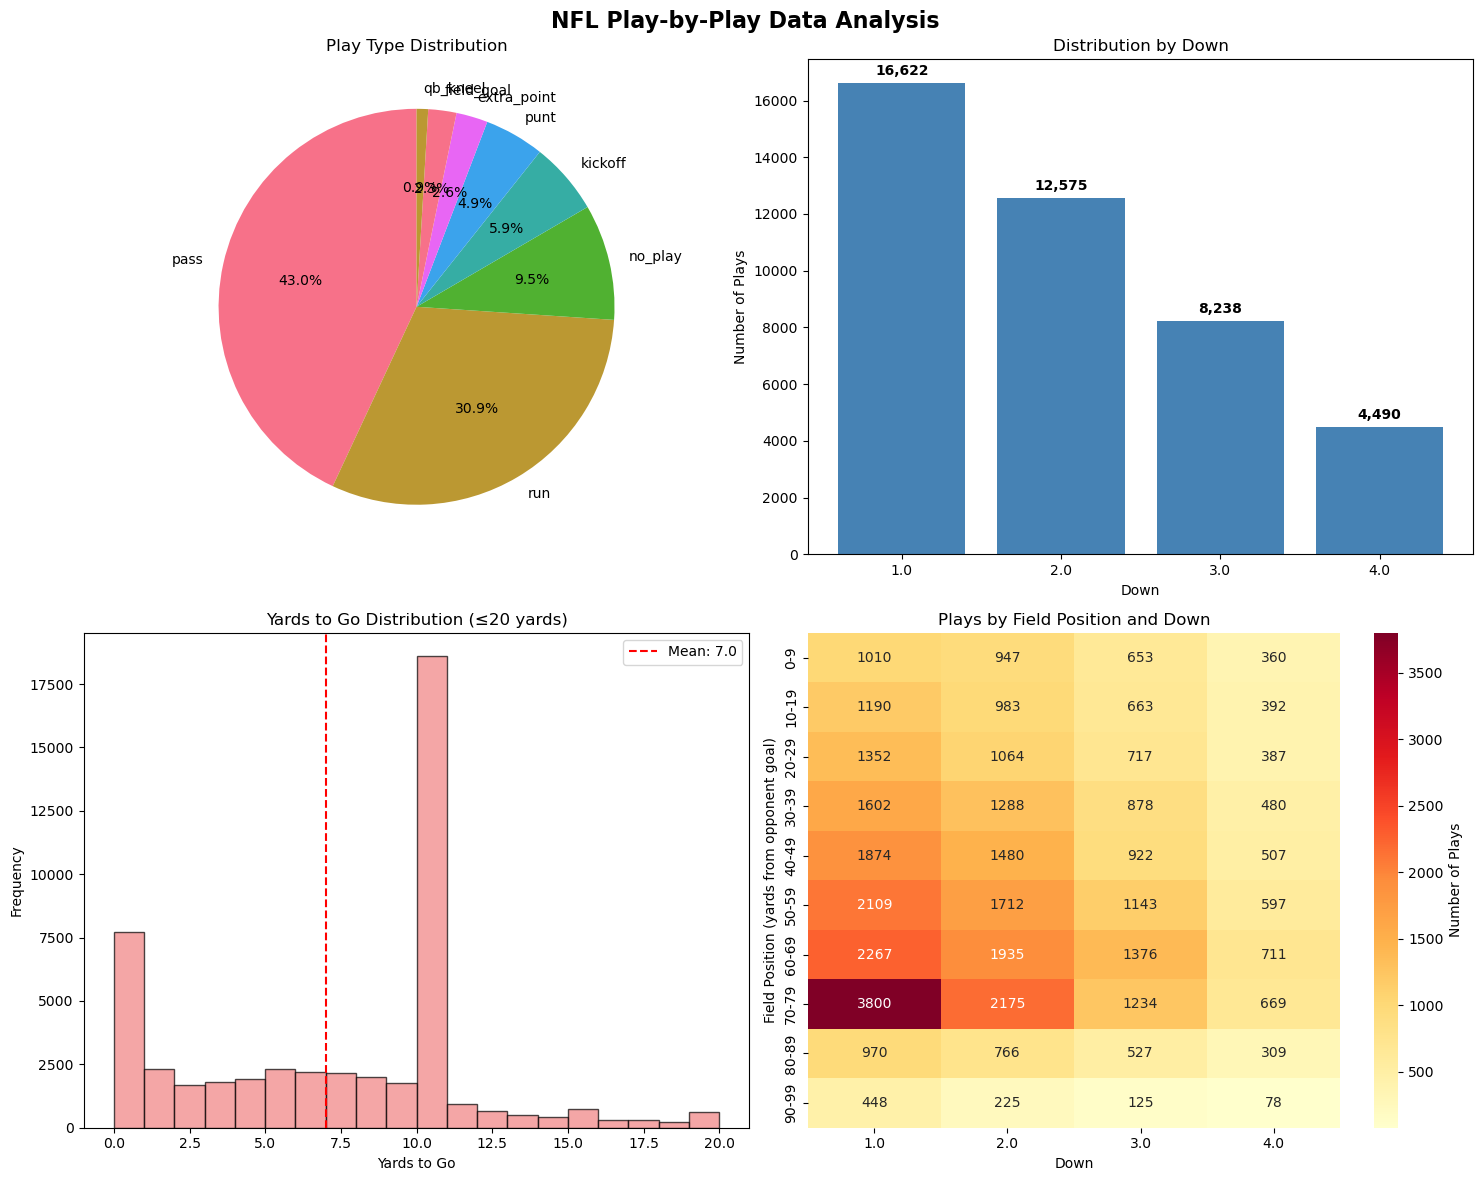

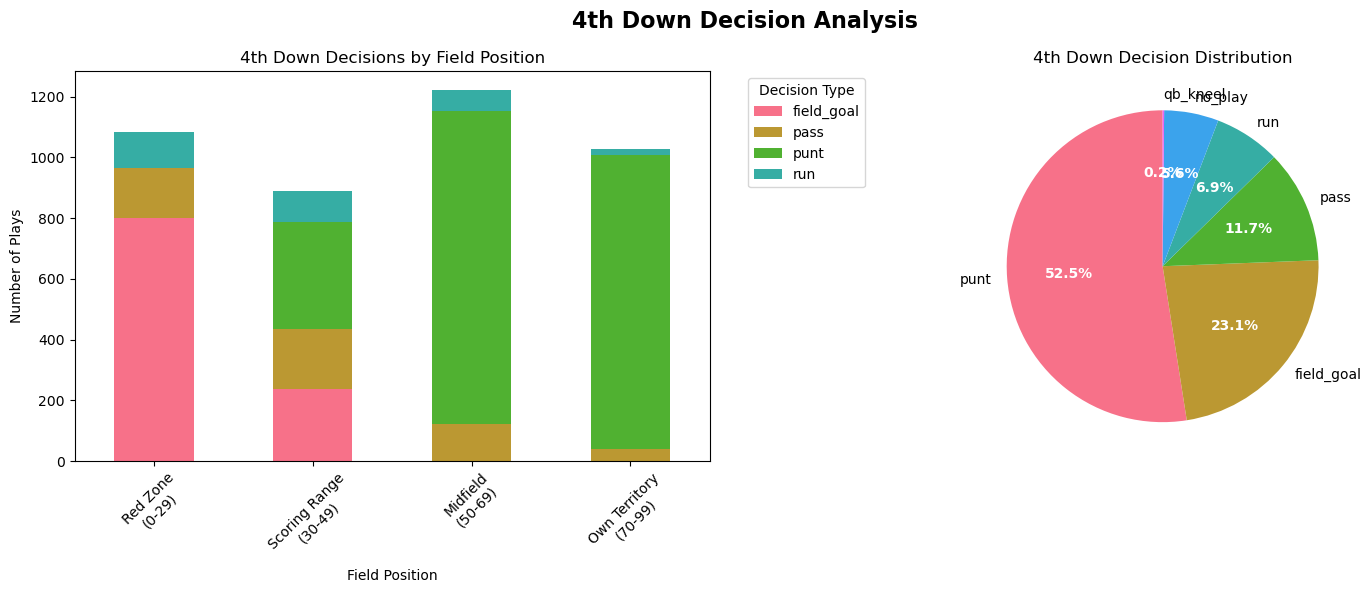

In [6]:
if nfl_data is not None and len(nfl_data) > 0:
    # Set up plotting style
    plt.style.use('default')
    sns.set_palette("husl")
    
    # Create subplots for multiple visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('NFL Play-by-Play Data Analysis', fontsize=16, fontweight='bold')
    
    # 1. Play type distribution
    if 'play_type' in nfl_data.columns:
        play_counts = nfl_data['play_type'].value_counts().head(8)
        axes[0, 0].pie(play_counts.values, labels=play_counts.index, autopct='%1.1f%%', startangle=90)
        axes[0, 0].set_title('Play Type Distribution')
    
    # 2. Down distribution
    if 'down' in nfl_data.columns:
        down_counts = nfl_data['down'].value_counts().sort_index()
        axes[0, 1].bar(down_counts.index.astype(str), down_counts.values, color='steelblue')
        axes[0, 1].set_title('Distribution by Down')
        axes[0, 1].set_xlabel('Down')
        axes[0, 1].set_ylabel('Number of Plays')
        
        # Add value labels on bars
        for i, v in enumerate(down_counts.values):
            axes[0, 1].text(i, v + max(down_counts.values)*0.01, f'{v:,}', 
                           ha='center', va='bottom', fontweight='bold')
    
    # 3. Yards to go distribution
    if 'ydstogo' in nfl_data.columns:
        # Filter out extreme outliers for better visualization
        yards_data = nfl_data['ydstogo'][nfl_data['ydstogo'] <= 20]
        axes[1, 0].hist(yards_data, bins=20, color='lightcoral', alpha=0.7, edgecolor='black')
        axes[1, 0].set_title('Yards to Go Distribution (≤20 yards)')
        axes[1, 0].set_xlabel('Yards to Go')
        axes[1, 0].set_ylabel('Frequency')
        axes[1, 0].axvline(yards_data.mean(), color='red', linestyle='--', 
                          label=f'Mean: {yards_data.mean():.1f}')
        axes[1, 0].legend()
    
    # 4. Field position heatmap
    if 'yardline_100' in nfl_data.columns and 'down' in nfl_data.columns:
        # Create bins for field position
        field_bins = list(range(0, 101, 10))
        nfl_data_copy = nfl_data.copy()
        nfl_data_copy['field_zone'] = pd.cut(nfl_data_copy['yardline_100'], 
                                           bins=field_bins, 
                                           labels=[f'{i}-{i+9}' for i in range(0, 100, 10)])
        
        # Create crosstab
        field_down_crosstab = pd.crosstab(nfl_data_copy['field_zone'], nfl_data_copy['down'])
        
        # Create heatmap
        sns.heatmap(field_down_crosstab, annot=True, fmt='d', cmap='YlOrRd', 
                   ax=axes[1, 1], cbar_kws={'label': 'Number of Plays'})
        axes[1, 1].set_title('Plays by Field Position and Down')
        axes[1, 1].set_xlabel('Down')
        axes[1, 1].set_ylabel('Field Position (yards from opponent goal)')
    
    plt.tight_layout()
    plt.show()
    
    # Additional 4th down specific visualization
    if 'down' in nfl_data.columns:
        fourth_downs = nfl_data[nfl_data['down'] == 4]
        
        if len(fourth_downs) > 0:
            fig, axes = plt.subplots(1, 2, figsize=(15, 6))
            fig.suptitle('4th Down Decision Analysis', fontsize=16, fontweight='bold')
            
            # 4th down decisions by field position
            if 'yardline_100' in fourth_downs.columns and 'play_type' in fourth_downs.columns:
                # Group field positions
                fourth_downs_copy = fourth_downs.copy()
                field_bins = [0, 30, 50, 70, 100]
                field_labels = ['Red Zone\n(0-29)', 'Scoring Range\n(30-49)', 
                              'Midfield\n(50-69)', 'Own Territory\n(70-99)']
                fourth_downs_copy['field_category'] = pd.cut(fourth_downs_copy['yardline_100'], 
                                                           bins=field_bins, 
                                                           labels=field_labels)
                
                # Get top decision types
                top_decisions = fourth_downs['play_type'].value_counts().head(4).index
                fourth_downs_filtered = fourth_downs_copy[fourth_downs_copy['play_type'].isin(top_decisions)]
                
                decision_field_crosstab = pd.crosstab(fourth_downs_filtered['field_category'], 
                                                    fourth_downs_filtered['play_type'])
                
                decision_field_crosstab.plot(kind='bar', ax=axes[0], stacked=True)
                axes[0].set_title('4th Down Decisions by Field Position')
                axes[0].set_xlabel('Field Position')
                axes[0].set_ylabel('Number of Plays')
                axes[0].legend(title='Decision Type', bbox_to_anchor=(1.05, 1), loc='upper left')
                axes[0].tick_params(axis='x', rotation=45)
            
            # 4th down success rate analysis (if we have outcome data)
            if 'play_type' in fourth_downs.columns:
                decision_counts = fourth_downs['play_type'].value_counts().head(6)
                colors = sns.color_palette("husl", len(decision_counts))
                
                wedges, texts, autotexts = axes[1].pie(decision_counts.values, 
                                                      labels=decision_counts.index, 
                                                      autopct='%1.1f%%', 
                                                      startangle=90,
                                                      colors=colors)
                axes[1].set_title('4th Down Decision Distribution')
                
                # Make percentage text bold
                for autotext in autotexts:
                    autotext.set_color('white')
                    autotext.set_fontweight('bold')
            
            plt.tight_layout()
            plt.show()
else:
    print("❌ No data available for visualization.")

## Game-Specific Analysis

Analyze specific games using the backend API to see individual game patterns.

In [7]:
# Get available games from the backend
if backend_available:
    try:
        print("🏈 AVAILABLE GAMES")
        print("=" * 50)
        
        response = requests.get(f'{BACKEND_URL}/api/games')
        if response.status_code == 200:
            games = response.json()
            print(f"Found {len(games)} games available")
            
            # Show first few games
            for i, game in enumerate(games[:5]):
                print(f"\n🏟️ Game {i+1}:")
                print(f"   ID: {game['game_id']}")
                print(f"   Matchup: {game['away_team']} @ {game['home_team']}")
                print(f"   Date: {game['game_date']}")
                print(f"   Plays: {game['play_count']}")
            
            if len(games) > 5:
                print(f"\n... and {len(games) - 5} more games")
            
            # Let's analyze the first game in detail
            if games:
                sample_game = games[0]
                print(f"\n🔍 DETAILED ANALYSIS: {sample_game['away_team']} @ {sample_game['home_team']}")
                print("=" * 60)
                
                game_data = get_game_data(sample_game['game_id'])
                
                if game_data is not None and len(game_data) > 0:
                    print(f"📊 Game Statistics:")
                    print(f"   Total plays: {len(game_data)}")
                    
                    if 'play_type' in game_data.columns:
                        print(f"   Play types: {game_data['play_type'].nunique()}")
                        top_plays = game_data['play_type'].value_counts().head(5)
                        print("   Most common plays:")
                        for play_type, count in top_plays.items():
                            print(f"     • {play_type}: {count}")
                    
                    if 'down' in game_data.columns:
                        print(f"   Downs distribution:")
                        for down in sorted(game_data['down'].unique()):
                            count = len(game_data[game_data['down'] == down])
                            print(f"     • {down} down: {count}")
                    
                    # Show scoring plays if available
                    if 'touchdown' in game_data.columns and 'field_goal_result' in game_data.columns:
                        touchdowns = len(game_data[game_data['touchdown'] == 1])
                        field_goals = len(game_data[game_data['field_goal_result'].notna()])
                        print(f"   Scoring plays:")
                        print(f"     • Touchdowns: {touchdowns}")
                        print(f"     • Field goal attempts: {field_goals}")
                    
                    # Show sample plays
                    print(f"\n📝 Sample plays from this game:")
                    if 'desc' in game_data.columns:
                        sample_plays = game_data['desc'].dropna().head(3)
                        for i, desc in enumerate(sample_plays, 1):
                            print(f"   {i}. {desc[:100]}{'...' if len(desc) > 100 else ''}")
        else:
            print(f"❌ Failed to get games: HTTP {response.status_code}")
            
    except Exception as e:
        print(f"❌ Error getting games: {e}")
else:
    print("❌ Backend not available. Cannot analyze specific games.")

🏈 AVAILABLE GAMES
Found 285 games available

🏟️ Game 1:
   ID: 2023_01_ARI_WAS
   Matchup: ARI @ WAS
❌ Error getting games: 'game_date'


## Next Steps for AI Agent Development

Based on the data analysis above, here are the key considerations for building a 4th down decision AI agent.

### Key Features for 4th Down Decision Model

Based on the analysis, these features would be important for training an AI agent:

**Situational Features:**
- `down` (always 4 for our model)
- `ydstogo` - yards needed for first down
- `yardline_100` - distance from opponent's goal line
- `game_seconds_remaining` - time pressure factor
- `score_differential` - how much team is winning/losing by
- `timeouts_remaining` - available timeouts

**Contextual Features:**
- `posteam` - team making the decision (team tendencies)
- `defteam` - opposing team (defensive strength)
- `season` - rule changes and trends over time
- `week` - regular season vs playoffs
- `roof` - weather conditions (dome vs outdoor)

**Game State Features:**
- `qtr` - quarter of the game
- `wp` - win probability before the play
- `wpa` - win probability added by the play (target for training)

### Potential Targets for Supervised Learning

1. **Decision Classification:**
   - Go for it (run/pass)
   - Punt
   - Field goal attempt

2. **Success Prediction:**
   - Probability of conversion
   - Expected points from decision
   - Win probability change

### Model Approaches to Consider

1. **Traditional ML:** Random Forest, XGBoost for interpretability
2. **Deep Learning:** Neural networks for complex pattern recognition
3. **Reinforcement Learning:** Learn optimal policies through simulation

The data from this backend provides a solid foundation for any of these approaches!

In [8]:
nfl_data

,game_id,play_id,season,week,posteam,defteam,home_team,away_team,down,ydstogo,yardline_100,qtr,half_seconds_remaining,game_seconds_remaining,score_differential,posteam_timeouts_remaining,defteam_timeouts_remaining,roof,surface,temp,wind,play_type,field_goal_result,punt_blocked,wp,wpa,wp_post,ep,epa,drive,fixed_drive,drive_play_count,game_half,quarter_seconds_remaining,desc,name,yards_gained,rushing_yards,passing_yards,receiver,rusher,passer,interception,fumble,touchdown,safety,first_down,penalty,penalty_type,penalty_yards
0,2023_01_ARI_WAS,1.0,2023,1,NaN,NaN,WAS,ARI,NaN,0.0,NaN,1.0,1800.0,3600.0,NaN,NaN,NaN,outdoors,NaN,NaN,NaN,NaN,NaN,NaN,0.546262,0.000000,0.546262,1.474098,0.000000,NaN,1.0,NaN,Half1,900.0,GAME,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023_01_ARI_WAS,39.0,2023,1,WAS,ARI,WAS,ARI,NaN,0.0,35.0,1.0,1800.0,3600.0,0.0,3.0,3.0,outdoors,NaN,NaN,NaN,kickoff,NaN,0.0,0.546262,0.000000,0.546262,1.474098,0.000000,1.0,1.0,8.0,Half1,900.0,5-M.Prater kicks 65 yards from ARI 35 to end z...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2,2023_01_ARI_WAS,55.0,2023,1,WAS,ARI,WAS,ARI,1.0,10.0,75.0,1.0,1800.0,3600.0,0.0,3.0,3.0,outdoors,NaN,NaN,NaN,run,NaN,0.0,0.546262,-0.006641,0.539621,1.474098,-0.336103,1.0,1.0,8.0,Half1,900.0,(15:00) (Shotgun) 8-B.Robinson right tackle to...,B.Robinson,3.0,3.0,NaN,NaN,B.Robinson,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
3,2023_01_ARI_WAS,77.0,2023,1,WAS,ARI,WAS,ARI,2.0,7.0,72.0,1.0,1770.0,3570.0,0.0,3.0,3.0,outdoors,NaN,NaN,NaN,pass,NaN,0.0,0.539621,0.016367,0.555987,1.137994,0.703308,1.0,1.0,8.0,Half1,870.0,(14:30) (Shotgun) 14-S.Howell pass short right...,S.Howell,6.0,NaN,6.0,J.Dotson,NaN,S.Howell,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
4,2023_01_ARI_WAS,102.0,2023,1,WAS,ARI,WAS,ARI,3.0,1.0,66.0,1.0,1735.0,3535.0,0.0,3.0,3.0,outdoors,NaN,NaN,NaN,run,NaN,0.0,0.555987,0.016586,0.572573,1.841302,0.469799,1.0,1.0,8.0,Half1,835.0,(13:55) 23-C.Rodriguez left guard to WAS 36 fo...,C.Rodriguez,2.0,2.0,NaN,NaN,C.Rodriguez,NaN,0.0,0.0,0.0,0.0,1.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49660,2023_22_SF_KC,4791.0,2023,22,KC,SF,KC,SF,3.0,1.0,32.0,5.0,127.0,127.0,-3.0,1.0,1.0,dome,grass,NaN,NaN,run,NaN,0.0,0.648316,0.209521,0.857837,3.136118,1.728891,26.0,26.0,13.0,Overtime,127.0,(2:07) (Shotgun) 15-P.Mahomes scrambles up the...,P.Mahomes,19.0,19.0,NaN,NaN,NaN,P.Mahomes,0.0,0.0,0.0,0.0,1.0,0.0,NaN,NaN
49661,2023_22_SF_KC,4813.0,2023,22,KC,SF,KC,SF,1.0,10.0,13.0,5.0,86.0,86.0,-3.0,1.0,1.0,dome,grass,NaN,NaN,run,NaN,0.0,0.857837,-0.007961,0.849875,4.865008,-0.330699,26.0,26.0,13.0,Overtime,86.0,(1:26) (Shotgun) 10-I.Pacheco up the middle to...,I.Pacheco,3.0,3.0,NaN,NaN,I.Pacheco,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
49662,2023_22_SF_KC,4835.0,2023,22,KC,SF,KC,SF,2.0,7.0,10.0,5.0,50.0,50.0,-3.0,1.0,1.0,dome,grass,NaN,NaN,pass,NaN,0.0,0.849875,0.021764,0.871640,4.534309,-0.637115,26.0,26.0,13.0,Overtime,50.0,(:50) (Shotgun) 15-P.Mahomes pass short middle...,P.Mahomes,7.0,NaN,7.0,T.Kelce,NaN,P.Mahomes,0.0,0.0,0.0,0.0,1.0,0.0,NaN,NaN
49663,2023_22_SF_KC,4860.0,2023,22,KC,SF,KC,SF,1.0,3.0,3.0,5.0,6.0,6.0,-3.0,1.0,1.0,dome,grass,NaN,NaN,pass,NaN,0.0,0.871640,0.128360,1.000000,3.897194,3.102806,26.0,26.0,13.0,Overtime,6.0,(:06) (Shotgun) 15-P.Mahomes pass short right ...,P.Mahomes,3.0,NaN,3.0,M.Hardman,NaN,P.Mahomes,0.0,0.0,1.0,0.0,1.0,0.0,NaN,NaN


In [9]:
f = nfl_data[nfl_data['down']==4.0]

In [10]:
cols = ['wp', 'wpa', 'ep', 'epa', 'score_differential', 'ydstogo', 'down', 'yardline_100', 'season', 'week', 'posteam', 'defteam', 'play_id', 'play_type']

In [11]:
f[cols].dropna().sort_values('wpa')

,wp,wpa,ep,epa,score_differential,ydstogo,down,yardline_100,season,week,posteam,defteam,play_id,play_type
49647,0.988725,-0.514933,2.935563,0.064437,0.0,4.0,4.0,9.0,2023,22,SF,KC,4525.0,field_goal
43413,0.886908,-0.378335,-0.704724,-6.295276,7.0,17.0,4.0,64.0,2023,17,LA,NYG,4077.0,punt
7864,0.472001,-0.356254,1.940509,-1.940509,-1.0,6.0,4.0,28.0,2023,3,NO,GB,4395.0,field_goal
15944,0.418924,-0.353604,2.235236,-2.235236,-4.0,8.0,4.0,9.0,2023,6,SEA,CIN,3971.0,pass
15929,0.423379,-0.333811,2.710223,-3.204260,-4.0,6.0,4.0,6.0,2023,6,SEA,CIN,3683.0,pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17019,0.369137,0.383623,3.748707,3.251293,-5.0,1.0,4.0,1.0,2023,7,CLE,IND,4863.0,run
7125,0.606440,0.393560,1.383004,1.616996,0.0,5.0,4.0,35.0,2023,3,IND,BAL,5099.0,field_goal
42063,0.375673,0.405297,1.614940,1.385060,-1.0,7.0,4.0,36.0,2023,16,NYJ,WAS,4981.0,field_goal
37508,0.122009,0.433885,-2.017031,0.595633,0.0,31.0,4.0,94.0,2023,15,HOU,TEN,4339.0,punt


In [12]:
nfl_data

,game_id,play_id,season,week,posteam,defteam,home_team,away_team,down,ydstogo,yardline_100,qtr,half_seconds_remaining,game_seconds_remaining,score_differential,posteam_timeouts_remaining,defteam_timeouts_remaining,roof,surface,temp,wind,play_type,field_goal_result,punt_blocked,wp,wpa,wp_post,ep,epa,drive,fixed_drive,drive_play_count,game_half,quarter_seconds_remaining,desc,name,yards_gained,rushing_yards,passing_yards,receiver,rusher,passer,interception,fumble,touchdown,safety,first_down,penalty,penalty_type,penalty_yards
0,2023_01_ARI_WAS,1.0,2023,1,NaN,NaN,WAS,ARI,NaN,0.0,NaN,1.0,1800.0,3600.0,NaN,NaN,NaN,outdoors,NaN,NaN,NaN,NaN,NaN,NaN,0.546262,0.000000,0.546262,1.474098,0.000000,NaN,1.0,NaN,Half1,900.0,GAME,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023_01_ARI_WAS,39.0,2023,1,WAS,ARI,WAS,ARI,NaN,0.0,35.0,1.0,1800.0,3600.0,0.0,3.0,3.0,outdoors,NaN,NaN,NaN,kickoff,NaN,0.0,0.546262,0.000000,0.546262,1.474098,0.000000,1.0,1.0,8.0,Half1,900.0,5-M.Prater kicks 65 yards from ARI 35 to end z...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2,2023_01_ARI_WAS,55.0,2023,1,WAS,ARI,WAS,ARI,1.0,10.0,75.0,1.0,1800.0,3600.0,0.0,3.0,3.0,outdoors,NaN,NaN,NaN,run,NaN,0.0,0.546262,-0.006641,0.539621,1.474098,-0.336103,1.0,1.0,8.0,Half1,900.0,(15:00) (Shotgun) 8-B.Robinson right tackle to...,B.Robinson,3.0,3.0,NaN,NaN,B.Robinson,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
3,2023_01_ARI_WAS,77.0,2023,1,WAS,ARI,WAS,ARI,2.0,7.0,72.0,1.0,1770.0,3570.0,0.0,3.0,3.0,outdoors,NaN,NaN,NaN,pass,NaN,0.0,0.539621,0.016367,0.555987,1.137994,0.703308,1.0,1.0,8.0,Half1,870.0,(14:30) (Shotgun) 14-S.Howell pass short right...,S.Howell,6.0,NaN,6.0,J.Dotson,NaN,S.Howell,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
4,2023_01_ARI_WAS,102.0,2023,1,WAS,ARI,WAS,ARI,3.0,1.0,66.0,1.0,1735.0,3535.0,0.0,3.0,3.0,outdoors,NaN,NaN,NaN,run,NaN,0.0,0.555987,0.016586,0.572573,1.841302,0.469799,1.0,1.0,8.0,Half1,835.0,(13:55) 23-C.Rodriguez left guard to WAS 36 fo...,C.Rodriguez,2.0,2.0,NaN,NaN,C.Rodriguez,NaN,0.0,0.0,0.0,0.0,1.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49660,2023_22_SF_KC,4791.0,2023,22,KC,SF,KC,SF,3.0,1.0,32.0,5.0,127.0,127.0,-3.0,1.0,1.0,dome,grass,NaN,NaN,run,NaN,0.0,0.648316,0.209521,0.857837,3.136118,1.728891,26.0,26.0,13.0,Overtime,127.0,(2:07) (Shotgun) 15-P.Mahomes scrambles up the...,P.Mahomes,19.0,19.0,NaN,NaN,NaN,P.Mahomes,0.0,0.0,0.0,0.0,1.0,0.0,NaN,NaN
49661,2023_22_SF_KC,4813.0,2023,22,KC,SF,KC,SF,1.0,10.0,13.0,5.0,86.0,86.0,-3.0,1.0,1.0,dome,grass,NaN,NaN,run,NaN,0.0,0.857837,-0.007961,0.849875,4.865008,-0.330699,26.0,26.0,13.0,Overtime,86.0,(1:26) (Shotgun) 10-I.Pacheco up the middle to...,I.Pacheco,3.0,3.0,NaN,NaN,I.Pacheco,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
49662,2023_22_SF_KC,4835.0,2023,22,KC,SF,KC,SF,2.0,7.0,10.0,5.0,50.0,50.0,-3.0,1.0,1.0,dome,grass,NaN,NaN,pass,NaN,0.0,0.849875,0.021764,0.871640,4.534309,-0.637115,26.0,26.0,13.0,Overtime,50.0,(:50) (Shotgun) 15-P.Mahomes pass short middle...,P.Mahomes,7.0,NaN,7.0,T.Kelce,NaN,P.Mahomes,0.0,0.0,0.0,0.0,1.0,0.0,NaN,NaN
49663,2023_22_SF_KC,4860.0,2023,22,KC,SF,KC,SF,1.0,3.0,3.0,5.0,6.0,6.0,-3.0,1.0,1.0,dome,grass,NaN,NaN,pass,NaN,0.0,0.871640,0.128360,1.000000,3.897194,3.102806,26.0,26.0,13.0,Overtime,6.0,(:06) (Shotgun) 15-P.Mahomes pass short right ...,P.Mahomes,3.0,NaN,3.0,M.Hardman,NaN,P.Mahomes,0.0,0.0,1.0,0.0,1.0,0.0,NaN,NaN


In [13]:
f.columns.tolist()

['game_id',
 'play_id',
 'season',
 'week',
 'posteam',
 'defteam',
 'home_team',
 'away_team',
 'down',
 'ydstogo',
 'yardline_100',
 'qtr',
 'half_seconds_remaining',
 'game_seconds_remaining',
 'score_differential',
 'posteam_timeouts_remaining',
 'defteam_timeouts_remaining',
 'roof',
 'surface',
 'temp',
 'wind',
 'play_type',
 'field_goal_result',
 'punt_blocked',
 'wp',
 'wpa',
 'wp_post',
 'ep',
 'epa',
 'drive',
 'fixed_drive',
 'drive_play_count',
 'game_half',
 'quarter_seconds_remaining',
 'desc',
 'name',
 'yards_gained',
 'rushing_yards',
 'passing_yards',
 'receiver',
 'rusher',
 'passer',
 'interception',
 'fumble',
 'touchdown',
 'safety',
 'first_down',
 'penalty',
 'penalty_type',
 'penalty_yards']

In [14]:
f

,game_id,play_id,season,week,posteam,defteam,home_team,away_team,down,ydstogo,yardline_100,qtr,half_seconds_remaining,game_seconds_remaining,score_differential,posteam_timeouts_remaining,defteam_timeouts_remaining,roof,surface,temp,wind,play_type,field_goal_result,punt_blocked,wp,wpa,wp_post,ep,epa,drive,fixed_drive,drive_play_count,game_half,quarter_seconds_remaining,desc,name,yards_gained,rushing_yards,passing_yards,receiver,rusher,passer,interception,fumble,touchdown,safety,first_down,penalty,penalty_type,penalty_yards
10,2023_01_ARI_WAS,245.0,2023,1,WAS,ARI,WAS,ARI,4.0,7.0,49.0,1.0,1568.0,3368.0,0.0,3.0,3.0,outdoors,NaN,NaN,NaN,punt,NaN,0.0,0.496160,0.021550,0.517710,0.144536,-0.415890,1.0,1.0,8.0,Half1,668.0,"(11:08) 5-T.Way punts 42 yards to ARI 7, Cente...",NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,1.0,Illegal Block Above the Waist,10.0
17,2023_01_ARI_WAS,427.0,2023,1,ARI,WAS,WAS,ARI,4.0,8.0,70.0,1.0,1365.0,3165.0,0.0,3.0,3.0,outdoors,NaN,NaN,NaN,punt,NaN,0.0,0.432813,0.038686,0.471498,-1.407519,1.075530,2.0,2.0,6.0,Half1,465.0,"(7:45) 16-N.Cooney punts 51 yards to WAS 19, C...",NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,1.0,Illegal Block Above the Waist,10.0
36,2023_01_ARI_WAS,958.0,2023,1,ARI,WAS,WAS,ARI,4.0,9.0,11.0,1.0,956.0,2756.0,-7.0,2.0,3.0,outdoors,NaN,NaN,NaN,field_goal,made,0.0,0.313076,0.032166,0.345242,2.874272,0.125728,4.0,4.0,8.0,Half1,56.0,"(:56) 5-M.Prater 28 yard field goal is GOOD, C...",NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
46,2023_01_ARI_WAS,1237.0,2023,1,ARI,WAS,WAS,ARI,4.0,9.0,36.0,2.0,811.0,2611.0,-4.0,2.0,3.0,outdoors,NaN,NaN,NaN,field_goal,made,0.0,0.383763,0.015041,0.398805,0.901252,2.098748,6.0,6.0,4.0,Half1,811.0,"(13:31) 5-M.Prater 54 yard field goal is GOOD,...",NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
60,2023_01_ARI_WAS,1601.0,2023,1,ARI,WAS,WAS,ARI,4.0,11.0,85.0,2.0,384.0,2184.0,-1.0,2.0,3.0,outdoors,NaN,NaN,NaN,punt,NaN,0.0,0.390952,-0.041274,0.349678,-1.932299,-0.807140,8.0,8.0,3.0,Half1,384.0,"(6:24) 16-N.Cooney punts 34 yards to ARI 49, C...",NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49589,2023_22_SF_KC,3156.0,2023,22,SF,KC,KC,SF,4.0,3.0,15.0,4.0,766.0,766.0,-3.0,2.0,2.0,dome,grass,NaN,NaN,pass,NaN,0.0,0.444412,0.101789,0.546201,2.782424,2.397201,20.0,20.0,12.0,Half2,766.0,(12:46) (Shotgun) 13-B.Purdy pass short right ...,B.Purdy,4.0,NaN,4.0,G.Kittle,NaN,B.Purdy,0.0,0.0,0.0,0.0,1.0,0.0,NaN,NaN
49605,2023_22_SF_KC,3534.0,2023,22,KC,SF,KC,SF,4.0,6.0,6.0,4.0,349.0,349.0,-3.0,2.0,2.0,dome,grass,NaN,NaN,field_goal,made,0.0,0.529621,-0.003928,0.525693,2.969886,0.030114,21.0,21.0,12.0,Half2,349.0,"(5:49) 7-H.Butker 24 yard field goal is GOOD, ...",NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
49613,2023_22_SF_KC,3733.0,2023,22,SF,KC,KC,SF,4.0,5.0,35.0,4.0,117.0,117.0,0.0,2.0,2.0,dome,grass,NaN,NaN,field_goal,made,0.0,0.533539,0.120908,0.654447,1.442558,1.557442,22.0,22.0,7.0,Half2,117.0,"(1:57) 4-J.Moody 53 yard field goal is GOOD, C...",NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
49647,2023_22_SF_KC,4525.0,2023,22,SF,KC,KC,SF,4.0,4.0,9.0,5.0,445.0,445.0,0.0,2.0,2.0,dome,grass,NaN,NaN,field_goal,made,0.0,0.988725,-0.514933,0.473792,2.935563,0.064437,25.0,25.0,13.0,Overtime,445.0,"(7:25) 4-J.Moody 27 yard field goal is GOOD, C...",NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN


In [17]:
# pip install pandas scikit-learn xgboost pyarrow

import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

# ------------------------------------------------------------
# df is your play-by-play DataFrame with these columns:
# ['wp','wpa','ep','epa','score_differential','ydstogo','down',
#  'yardline_100','season','week','posteam','defteam','play_id','play_type']
# ------------------------------------------------------------

# --- 1) Choose features (constraints + play tag)
FEATURES = ['score_differential', 'ydstogo', 'yardline_100', 'play_type']
TARGET   = 'wpa'

# --- 2) Keep only 4th downs
df4 = nfl_data[nfl_data['down'] == 4].copy()

# --- 3) Clean and subset
use_cols = FEATURES + [TARGET, 'season', 'week', 'play_id']
df4 = df4[[c for c in use_cols if c in df4.columns]].dropna(subset=[TARGET])

# --- 4) Chronological 80/20 train-test split
sort_cols = [c for c in ['season', 'week', 'play_id'] if c in df4.columns]
if sort_cols:
    df4 = df4.sort_values(sort_cols)

split_idx = int(len(df4) * 0.8)
train = df4.iloc[:split_idx].copy()
test  = df4.iloc[split_idx:].copy()

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

# --- 5) Preprocess: impute numerics, one-hot encode categoricals
num_cols = X_train.select_dtypes(include=['number', 'bool']).columns.tolist()
cat_cols = [c for c in FEATURES if c not in num_cols]

pre = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# --- 6) Define and train the model
model = Pipeline(steps=[
    ('pre', pre),
    ('xgb', XGBRegressor(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective='reg:squarederror',
        random_state=42
    ))
])

model.fit(X_train, y_train)

# --- 7) Evaluate
pred = model.predict(X_test)
mae  = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))  # manual RMSE

print(f"Test MAE:  {mae:.5f}")
print(f"Test RMSE: {rmse:.5f}")

# --- 8) Example inference
example_state = {
    'score_differential': -3,   # losing by 3
    'ydstogo': 2,               # 2 yards to go
    'yardline_100': 44,         # ball on opponent 44
    'play_type': 'fg'
}
example_df = pd.DataFrame([example_state])
print("Predicted WPA:", float(model.predict(example_df)))


Test MAE:  0.03223
Test RMSE: 0.05736
Predicted WPA: 0.01563236117362976


In [18]:
example_df

,score_differential,ydstogo,yardline_100,play_type
0,-3,2,44,fg


In [19]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

# ------------------------------------------------------------
# df is your play-by-play DataFrame with these columns:
# ['wp','wpa','ep','epa','score_differential','ydstogo','down',
#  'yardline_100','season','week','posteam','defteam','play_id','play_type', ...]
# We'll also use/derive: 'game_seconds_remaining' (or qtr+quarter_seconds_remaining / half_seconds_remaining)
# ------------------------------------------------------------

df = nfl_data.copy()

# --- 0) Ensure we have game time left (game_seconds_remaining)
if 'game_seconds_remaining' not in df.columns:
    if {'qtr', 'quarter_seconds_remaining'}.issubset(df.columns):
        # Regulation only (qtr 1..4). If OT (qtr >= 5), treat as 0 remaining (safe baseline).
        # game_seconds_remaining = seconds left in current quarter + remaining full quarters
        df['game_seconds_remaining'] = (
            df['quarter_seconds_remaining']
            + np.clip(4 - df['qtr'].astype(int), 0, None) * 900
        )
        df.loc[df['qtr'] >= 5, 'game_seconds_remaining'] = 0
    elif {'qtr', 'half_seconds_remaining'}.issubset(df.columns):
        # Approximation using half-seconds:
        # Q1/Q2: remaining in 1st half + full 2nd half (1800s)
        # Q3/Q4: remaining in 2nd half
        df['game_seconds_remaining'] = np.where(
            df['qtr'].astype(int) <= 2,
            df['half_seconds_remaining'].astype(float) + 1800.0,
            df['half_seconds_remaining'].astype(float)
        )
        df.loc[df['qtr'] >= 5, 'game_seconds_remaining'] = 0
    else:
        raise ValueError(
            "No time columns found. Please include 'game_seconds_remaining' or "
            "('qtr' + 'quarter_seconds_remaining') or ('qtr' + 'half_seconds_remaining')."
        )

# --- 1) Choose features (constraints + play tag + time)
FEATURES = ['score_differential', 'ydstogo', 'yardline_100', 'game_seconds_remaining', 'play_type']
TARGET   = 'wpa'

# --- 2) Keep only 4th downs
df4 = df[df['down'] == 4].copy()

# --- 3) Clean and subset
use_cols = FEATURES + [TARGET, 'season', 'week', 'play_id']
df4 = df4[[c for c in use_cols if c in df4.columns]].dropna(subset=[TARGET])

# --- 4) Chronological 80/20 train-test split
sort_cols = [c for c in ['season', 'week', 'play_id'] if c in df4.columns]
if sort_cols:
    df4 = df4.sort_values(sort_cols)

split_idx = int(len(df4) * 0.8)
train = df4.iloc[:split_idx].copy()
test  = df4.iloc[split_idx:].copy()

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

# --- 5) Preprocess: impute numerics, one-hot encode categoricals
num_cols = X_train.select_dtypes(include=['number', 'bool']).columns.tolist()
cat_cols = [c for c in FEATURES if c not in num_cols]  # -> ['play_type'] here

pre = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# --- 6) Define and train the model
model = Pipeline(steps=[
    ('pre', pre),
    ('xgb', XGBRegressor(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective='reg:squarederror',
        random_state=42
    ))
])

model.fit(X_train, y_train)

# --- 7) Evaluate
pred = model.predict(X_test)
mae  = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))  # manual RMSE

print(f"Test MAE:  {mae:.5f}")
print(f"Test RMSE: {rmse:.5f}")

# --- 8) Example inference (now includes time left)
example_state = {
    'score_differential': -3,         # losing by 3
    'ydstogo': 10,                     # 2 yards to go
    'yardline_100': 23,               # ball on opponent 44
    'game_seconds_remaining': 120,    # 2 minutes left
    'play_type': 'run'                 # your categorical tag
}
example_df = pd.DataFrame([example_state])
print("Predicted WPA:", float(model.predict(example_df)))


Test MAE:  0.03157
Test RMSE: 0.05787
Predicted WPA: 0.060176216065883636


## Model Interpretability & Feature Analysis

Now let's visualize what factors are driving your XGBoost model's predictions to build intuition around the data.

🎯 FEATURE IMPORTANCE ANALYSIS

📊 XGBoost Built-in Feature Importance:


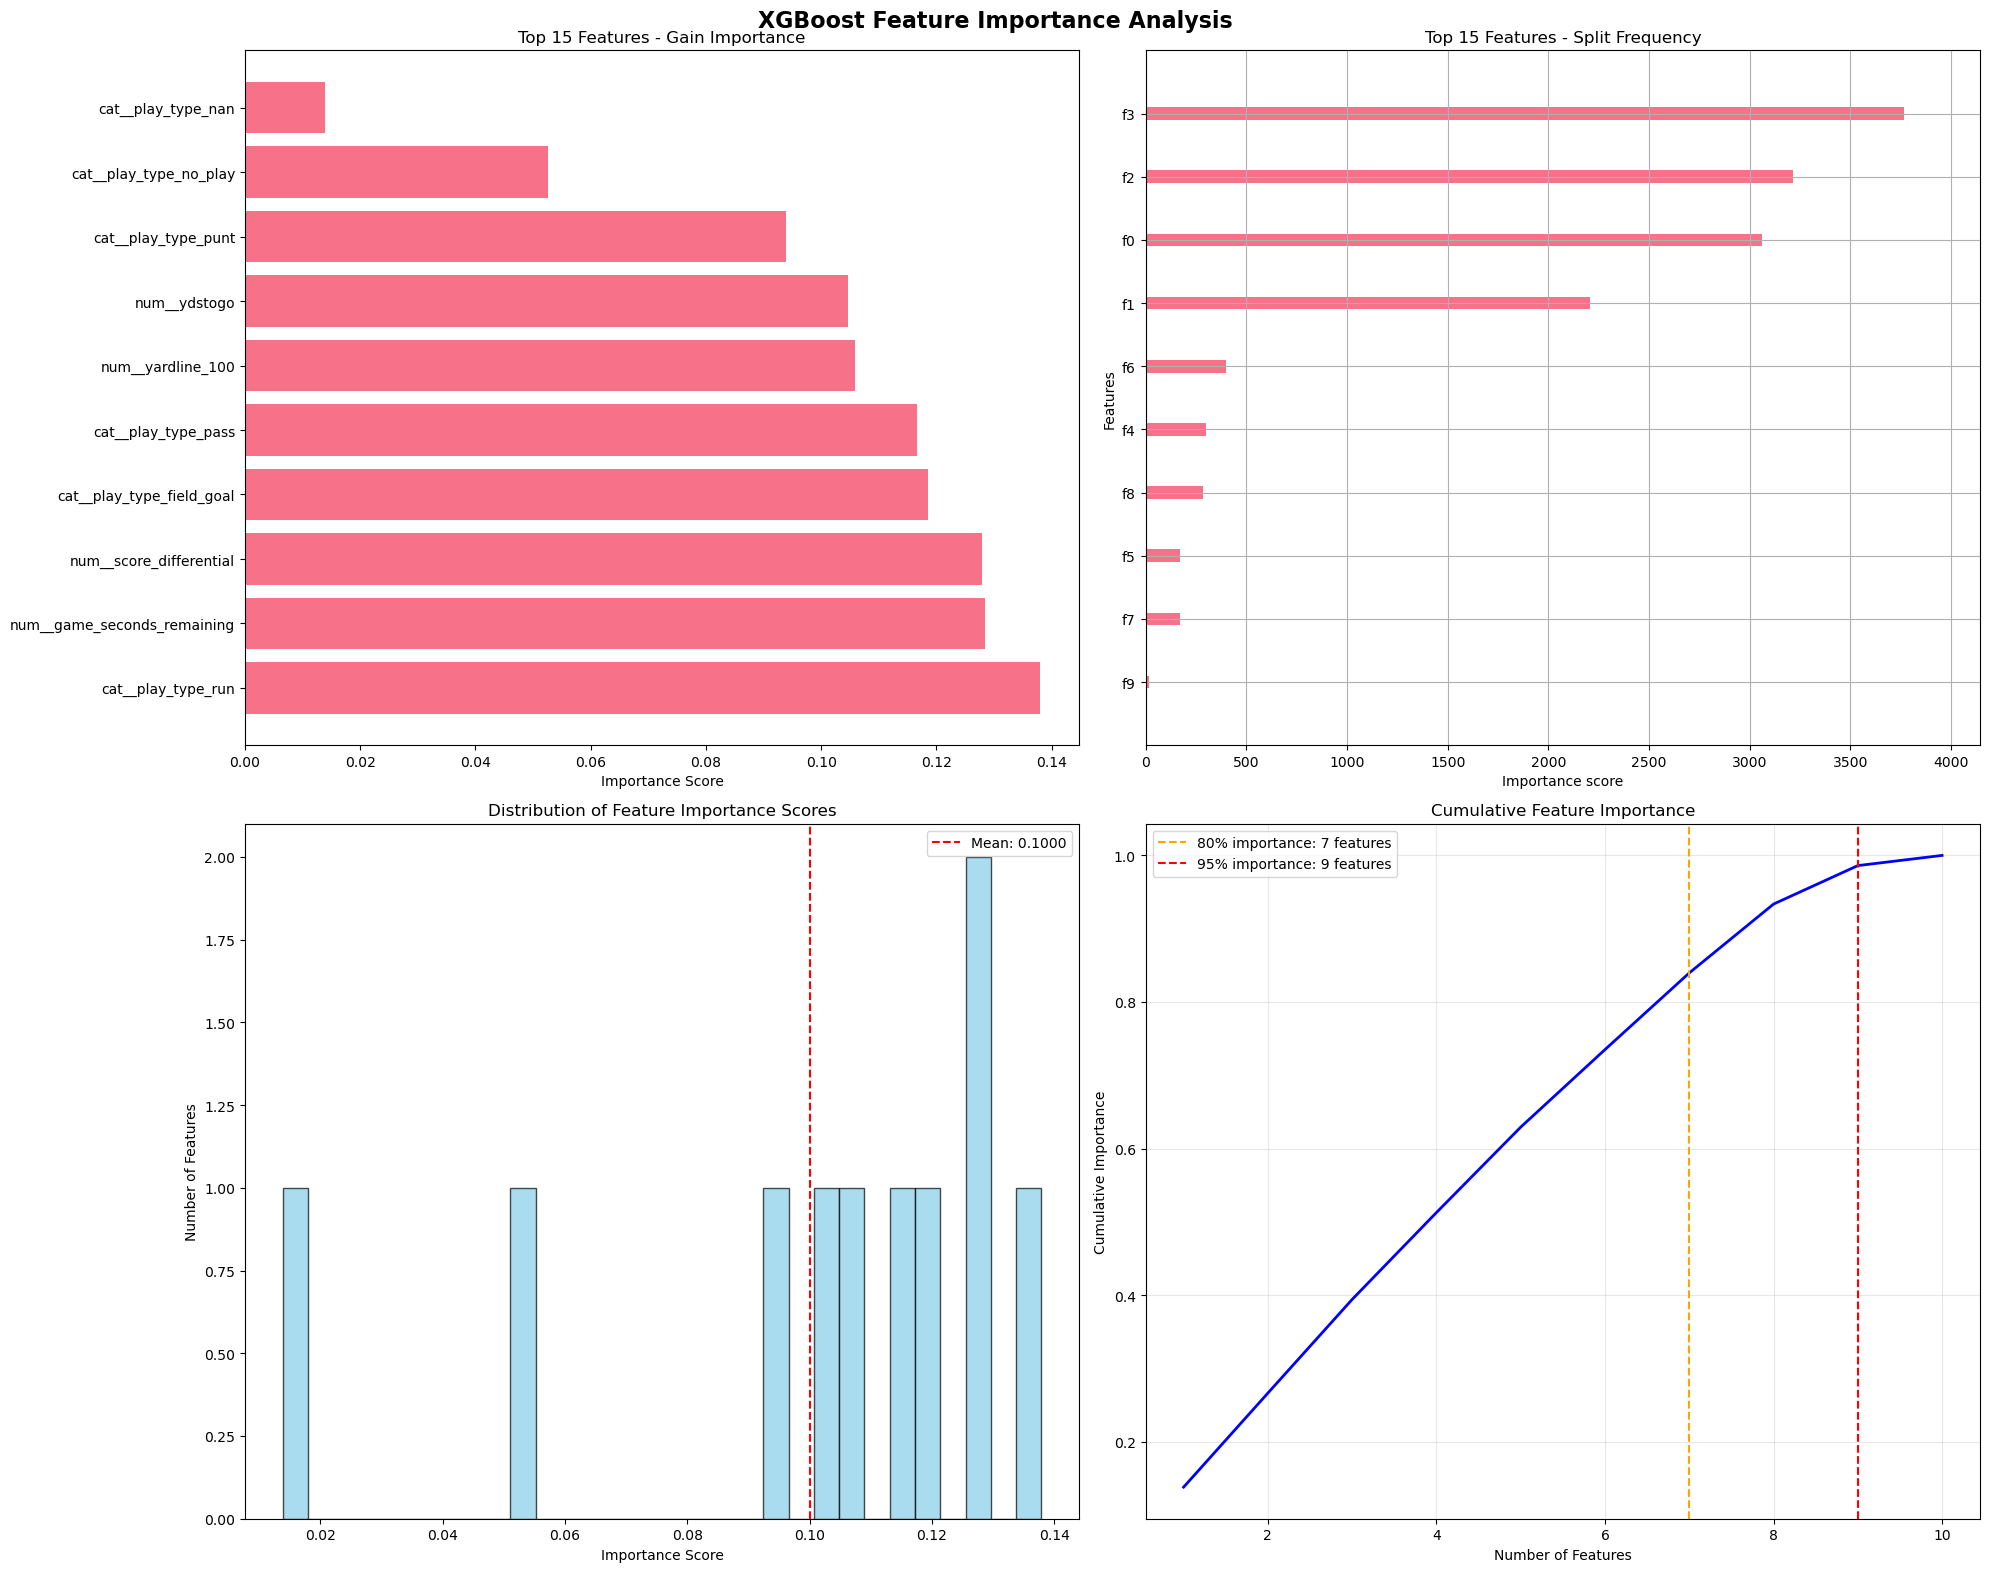


🏆 TOP 10 MOST IMPORTANT FEATURES:
    1. cat__play_type_run             | 0.1379
    2. num__game_seconds_remaining    | 0.1284
    3. num__score_differential        | 0.1278
    4. cat__play_type_field_goal      | 0.1186
    5. cat__play_type_pass            | 0.1165
    6. num__yardline_100              | 0.1058
    7. num__ydstogo                   | 0.1046
    8. cat__play_type_punt            | 0.0940
    9. cat__play_type_no_play         | 0.0525
   10. cat__play_type_nan             | 0.0139

ℹ️  Total features: 10
ℹ️  Features explaining 80% of importance: 7
ℹ️  Features explaining 95% of importance: 9


In [20]:
# Feature Importance Analysis
import xgboost as xgb
from sklearn.inspection import permutation_importance

print("🎯 FEATURE IMPORTANCE ANALYSIS")
print("=" * 50)

# Get the trained XGBoost model from your pipeline
xgb_model = model.named_steps['xgb']

# Method 1: Built-in XGBoost Feature Importance
print("\n📊 XGBoost Built-in Feature Importance:")

# Get feature names after preprocessing
if hasattr(model.named_steps['pre'], 'get_feature_names_out'):
    feature_names = model.named_steps['pre'].get_feature_names_out()
else:
    # Fallback if preprocessor doesn't have this method
    feature_names = [f'feature_{i}' for i in range(X_train.shape[1])]

# Create importance plots
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('XGBoost Feature Importance Analysis', fontsize=16, fontweight='bold')

# 1. Gain-based importance
importance_gain = xgb_model.feature_importances_
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance_gain
}).sort_values('importance', ascending=False)

# Top 15 features
top_features = importance_df.head(15)
axes[0, 0].barh(range(len(top_features)), top_features['importance'])
axes[0, 0].set_yticks(range(len(top_features)))
axes[0, 0].set_yticklabels(top_features['feature'])
axes[0, 0].set_title('Top 15 Features - Gain Importance')
axes[0, 0].set_xlabel('Importance Score')

# 2. Split-based importance (if available)
try:
    xgb.plot_importance(xgb_model, importance_type='weight', max_num_features=15, 
                       ax=axes[0, 1], show_values=False)
    axes[0, 1].set_title('Top 15 Features - Split Frequency')
except:
    axes[0, 1].text(0.5, 0.5, 'Split importance plot not available', 
                   ha='center', va='center', transform=axes[0, 1].transAxes)

# 3. Feature importance distribution
axes[1, 0].hist(importance_gain, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[1, 0].set_title('Distribution of Feature Importance Scores')
axes[1, 0].set_xlabel('Importance Score')
axes[1, 0].set_ylabel('Number of Features')
axes[1, 0].axvline(importance_gain.mean(), color='red', linestyle='--', 
                  label=f'Mean: {importance_gain.mean():.4f}')
axes[1, 0].legend()

# 4. Cumulative importance
cumulative_importance = np.cumsum(importance_df['importance'].values)
axes[1, 1].plot(range(1, len(cumulative_importance) + 1), cumulative_importance, 'b-', linewidth=2)
axes[1, 1].set_title('Cumulative Feature Importance')
axes[1, 1].set_xlabel('Number of Features')
axes[1, 1].set_ylabel('Cumulative Importance')
axes[1, 1].grid(True, alpha=0.3)

# Add lines for 80% and 95% importance thresholds
threshold_80 = np.where(cumulative_importance >= 0.8)[0]
threshold_95 = np.where(cumulative_importance >= 0.95)[0]

if len(threshold_80) > 0:
    axes[1, 1].axvline(threshold_80[0] + 1, color='orange', linestyle='--', 
                      label=f'80% importance: {threshold_80[0] + 1} features')
if len(threshold_95) > 0:
    axes[1, 1].axvline(threshold_95[0] + 1, color='red', linestyle='--', 
                      label=f'95% importance: {threshold_95[0] + 1} features')

axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Print top features with their importance scores
print(f"\n🏆 TOP 10 MOST IMPORTANT FEATURES:")
for i, (_, row) in enumerate(top_features.head(10).iterrows(), 1):
    print(f"   {i:2d}. {row['feature']:30s} | {row['importance']:.4f}")

print(f"\nℹ️  Total features: {len(feature_names)}")
print(f"ℹ️  Features explaining 80% of importance: {threshold_80[0] + 1 if len(threshold_80) > 0 else 'N/A'}")
print(f"ℹ️  Features explaining 95% of importance: {threshold_95[0] + 1 if len(threshold_95) > 0 else 'N/A'}")

In [21]:
# SHAP Analysis for Better Feature Understanding
try:
    import shap
    
    print("🔍 SHAP (SHapley Additive exPlanations) ANALYSIS")
    print("=" * 60)
    print("SHAP helps explain individual predictions and overall model behavior.")
    
    # Create SHAP explainer
    # Use a subset of data for faster computation
    sample_size = min(1000, len(X_test))
    X_sample = X_test.iloc[:sample_size]
    
    print(f"\nAnalyzing {sample_size} samples for SHAP explanation...")
    
    # Create explainer - TreeExplainer is optimized for tree models like XGBoost
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_sample)
    
    # SHAP Summary Plots
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    fig.suptitle('SHAP Feature Analysis', fontsize=16, fontweight='bold')
    
    # 1. Summary plot (bar) - Feature importance
    shap.summary_plot(shap_values, X_sample, feature_names=feature_names, 
                     plot_type="bar", show=False, max_display=15)
    plt.title('SHAP Feature Importance (Mean |SHAP value|)')
    plt.tight_layout()
    plt.show()
    
    # 2. Summary plot (beeswarm) - Feature effects
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_sample, feature_names=feature_names, 
                     show=False, max_display=15)
    plt.title('SHAP Summary Plot - Feature Effects on Model Output')
    plt.tight_layout()
    plt.show()
    
    # 3. Feature interaction analysis for top features
    print(f"\n🔗 FEATURE INTERACTIONS:")
    
    # Get top 5 features for interaction analysis
    feature_importance = np.abs(shap_values).mean(0)
    top_5_indices = np.argsort(feature_importance)[-5:]
    
    for i, idx in enumerate(top_5_indices):
        feature_name = feature_names[idx]
        avg_impact = feature_importance[idx]
        print(f"   {i+1}. {feature_name}: Avg |SHAP| = {avg_impact:.4f}")
    
    # 4. Waterfall plot for a sample prediction
    if len(X_sample) > 0:
        plt.figure(figsize=(12, 8))
        sample_idx = 0  # First sample
        shap.plots.waterfall(explainer.expected_value, shap_values[sample_idx], 
                           X_sample.iloc[sample_idx], feature_names=feature_names, 
                           show=False, max_display=15)
        plt.title(f'SHAP Waterfall Plot - Sample Prediction #{sample_idx + 1}')
        plt.tight_layout()
        plt.show()
        
        # Print prediction details
        prediction = model.predict(X_sample.iloc[[sample_idx]])[0]
        actual = y_test.iloc[sample_idx] if sample_idx < len(y_test) else "N/A"
        print(f"\n📊 Sample Prediction Analysis:")
        print(f"   Predicted value: {prediction:.4f}")
        print(f"   Actual value: {actual}")
        print(f"   Base value (model average): {explainer.expected_value:.4f}")
    
    print(f"\n💡 SHAP INTERPRETATION GUIDE:")
    print(f"   • Red points = Higher feature values")
    print(f"   • Blue points = Lower feature values") 
    print(f"   • X-axis = Impact on model output (SHAP value)")
    print(f"   • Features pushing prediction higher appear on right")
    print(f"   • Features pushing prediction lower appear on left")
    
except ImportError:
    print("❌ SHAP not available. Install with: pip install shap")
    print("   SHAP provides the best explanations for tree models like XGBoost")
    
except Exception as e:
    print(f"❌ Error running SHAP analysis: {e}")
    print("   This might be due to memory constraints or data compatibility issues")

🔍 SHAP (SHapley Additive exPlanations) ANALYSIS
SHAP helps explain individual predictions and overall model behavior.

Analyzing 897 samples for SHAP explanation...
❌ Error running SHAP analysis: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:play_type: object
   This might be due to memory constraints or data compatibility issues


📈 PARTIAL DEPENDENCE ANALYSIS
Shows how each feature individually affects predictions

Analyzing partial dependence for top 6 features:
   1. num__yardline_100
   2. cat__play_type_pass
   3. cat__play_type_field_goal
   4. num__score_differential
   5. num__game_seconds_remaining
   6. cat__play_type_run
   ⚠️  Could not plot cat__play_type_pass: all features must be in [0, 4] or [-5, 0]
   ⚠️  Could not plot cat__play_type_field_goal: The column #0 contains mixed data types. Finding unique categories fail due to sorting. It usually means that the column contains `np.nan` values together with `str` categories. Such use case is not yet supported in scikit-learn.
   ⚠️  Could not plot cat__play_type_run: all features must be in [0, 4] or [-5, 0]


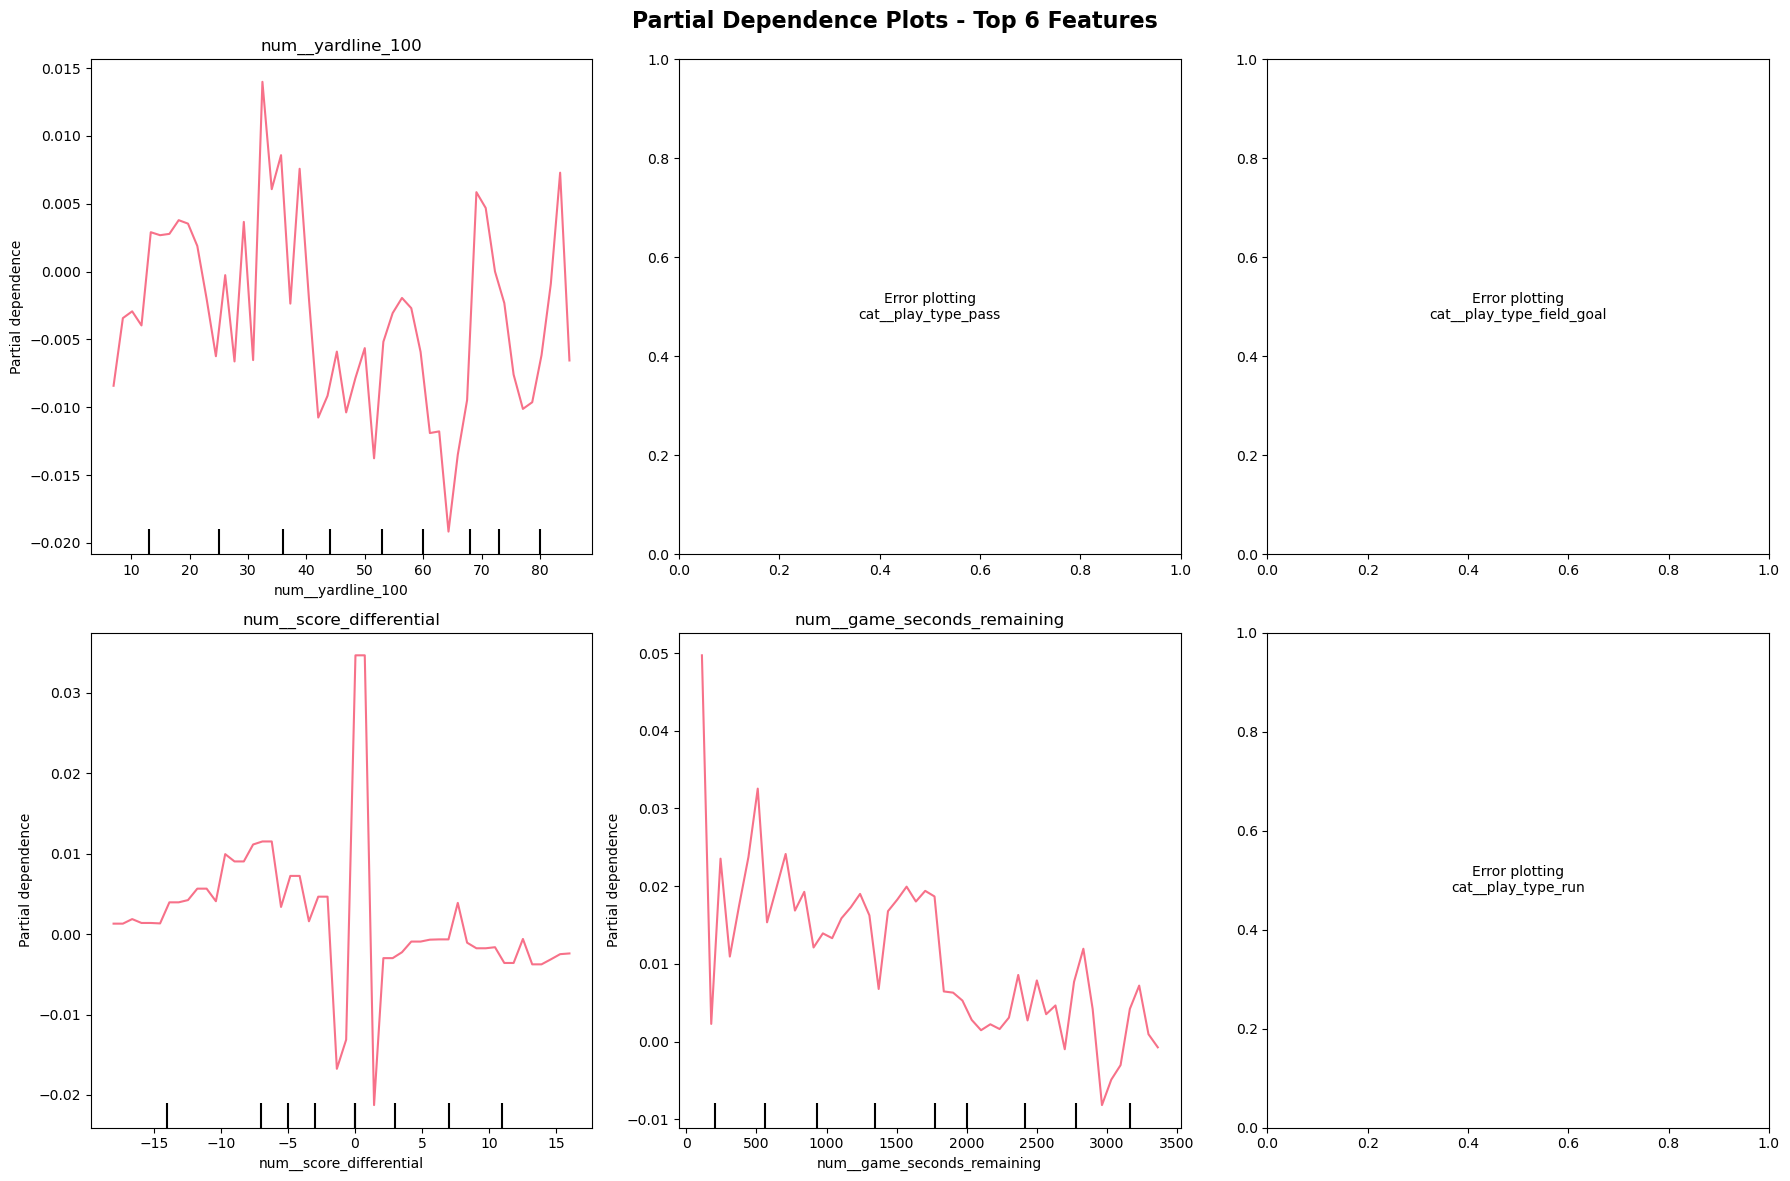


💡 PARTIAL DEPENDENCE INTERPRETATION:
   • Shows average model prediction vs feature value
   • Upward slope = feature increases prediction
   • Downward slope = feature decreases prediction
   • Flat line = feature has no effect
   • Curved lines = non-linear relationships


In [20]:
# Partial Dependence Plots - Understanding Feature Relationships
from sklearn.inspection import PartialDependenceDisplay

print("📈 PARTIAL DEPENDENCE ANALYSIS")
print("=" * 50)
print("Shows how each feature individually affects predictions")

try:
    # Get the top 6 most important features for PDP analysis
    importance_gain = xgb_model.feature_importances_
    top_feature_indices = np.argsort(importance_gain)[-6:]
    top_feature_names = [feature_names[i] for i in top_feature_indices]
    
    print(f"\nAnalyzing partial dependence for top 6 features:")
    for i, name in enumerate(top_feature_names):
        print(f"   {i+1}. {name}")
    
    # Create partial dependence plots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Partial Dependence Plots - Top 6 Features', fontsize=16, fontweight='bold')
    
    axes = axes.ravel()
    
    for i, feature_idx in enumerate(top_feature_indices):
        try:
            # Create partial dependence plot
            PartialDependenceDisplay.from_estimator(
                model, X_train, [feature_idx], 
                feature_names=feature_names,
                ax=axes[i], 
                grid_resolution=50
            )
            axes[i].set_title(f'{feature_names[feature_idx]}')
            
        except Exception as e:
            axes[i].text(0.5, 0.5, f'Error plotting\n{feature_names[feature_idx]}', 
                        ha='center', va='center', transform=axes[i].transAxes)
            print(f"   ⚠️  Could not plot {feature_names[feature_idx]}: {e}")
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n💡 PARTIAL DEPENDENCE INTERPRETATION:")
    print(f"   • Shows average model prediction vs feature value")
    print(f"   • Upward slope = feature increases prediction") 
    print(f"   • Downward slope = feature decreases prediction")
    print(f"   • Flat line = feature has no effect")
    print(f"   • Curved lines = non-linear relationships")
    
except Exception as e:
    print(f"❌ Error creating partial dependence plots: {e}")
    print("   This might be due to preprocessing issues or data types")

In [22]:
# Feature Correlation and Interaction Analysis
print("🔗 FEATURE CORRELATION & INTERACTION ANALYSIS")
print("=" * 60)

# Get feature correlation matrix (using original features before preprocessing if possible)
try:
    # If we have access to the original feature matrix
    if 'X_train' in locals() and hasattr(X_train, 'corr'):
        corr_matrix = X_train.corr()
        
        # Plot correlation heatmap for top features
        top_features_for_corr = importance_df.head(15)['feature'].tolist()
        
        # Try to map back to original column names (this might need adjustment based on your preprocessing)
        available_cols = [col for col in top_features_for_corr if col in X_train.columns]
        
        if len(available_cols) > 1:
            plt.figure(figsize=(12, 10))
            
            subset_corr = corr_matrix.loc[available_cols, available_cols]
            
            # Create correlation heatmap
            mask = np.triu(np.ones_like(subset_corr, dtype=bool))
            sns.heatmap(subset_corr, mask=mask, annot=True, cmap='RdBu_r', center=0,
                       square=True, fmt='.2f', cbar_kws={"shrink": .8})
            
            plt.title('Feature Correlation Matrix - Top Important Features')
            plt.tight_layout()
            plt.show()
            
            # Find highly correlated feature pairs
            high_corr_pairs = []
            for i in range(len(available_cols)):
                for j in range(i+1, len(available_cols)):
                    corr_val = subset_corr.iloc[i, j]
                    if abs(corr_val) > 0.7:  # High correlation threshold
                        high_corr_pairs.append((available_cols[i], available_cols[j], corr_val))
            
            if high_corr_pairs:
                print(f"\n⚠️  HIGH CORRELATION PAIRS (|r| > 0.7):")
                for feat1, feat2, corr in high_corr_pairs:
                    print(f"   • {feat1} ↔ {feat2}: r = {corr:.3f}")
                print(f"   Consider removing one feature from highly correlated pairs")
            else:
                print(f"\n✅ No highly correlated feature pairs found (threshold = 0.7)")
        else:
            print("   ⚠️  Could not map processed features back to original columns")
    
    # Feature interaction strength (approximate)
    print(f"\n🎯 TOP FEATURE INTERACTIONS (Estimated):")
    
    # Calculate feature interaction strength using SHAP values if available
    if 'shap_values' in locals():
        # Simple interaction approximation: features that vary together in SHAP values
        shap_df = pd.DataFrame(shap_values, columns=feature_names)
        
        top_5_features = importance_df.head(5)['feature'].tolist()
        available_features = [f for f in top_5_features if f in shap_df.columns]
        
        if len(available_features) >= 2:
            interaction_strength = {}
            
            for i, feat1 in enumerate(available_features):
                for feat2 in available_features[i+1:]:
                    # Correlation between SHAP values as proxy for interaction
                    shap_corr = shap_df[feat1].corr(shap_df[feat2])
                    interaction_strength[(feat1, feat2)] = abs(shap_corr)
            
            # Sort by interaction strength 
            sorted_interactions = sorted(interaction_strength.items(), 
                                       key=lambda x: x[1], reverse=True)
            
            for i, ((feat1, feat2), strength) in enumerate(sorted_interactions[:5]):
                print(f"   {i+1}. {feat1} × {feat2}: {strength:.3f}")
    
    print(f"\n💡 INTERACTION INSIGHTS:")
    print(f"   • High correlation = features move together")
    print(f"   • Strong interactions = features influence each other's impact")
    print(f"   • Consider feature engineering to capture interactions explicitly")
    
except Exception as e:
    print(f"❌ Error in correlation analysis: {e}")
    print("   This might be due to preprocessing steps or data structure")

🔗 FEATURE CORRELATION & INTERACTION ANALYSIS
   ⚠️  Could not map processed features back to original columns

🎯 TOP FEATURE INTERACTIONS (Estimated):

💡 INTERACTION INSIGHTS:
   • High correlation = features move together
   • Strong interactions = features influence each other's impact
   • Consider feature engineering to capture interactions explicitly


📊 MODEL PERFORMANCE BY FEATURE RANGES
Understanding how model performs across different feature value ranges
   ⚠️  Could not analyze cat__play_type_run: single positional indexer is out-of-bounds

📈 num__game_seconds_remaining Performance Analysis:
   Best performing range: Bin 5 (MAE: 0.0206)
   Worst performing range: Bin 1 (MAE: 0.0646)
   Trend: Relatively stable across feature range

📈 num__score_differential Performance Analysis:
   Best performing range: Bin 1 (MAE: 0.0136)
   Worst performing range: Bin 4 (MAE: 0.0509)
   Trend: Relatively stable across feature range


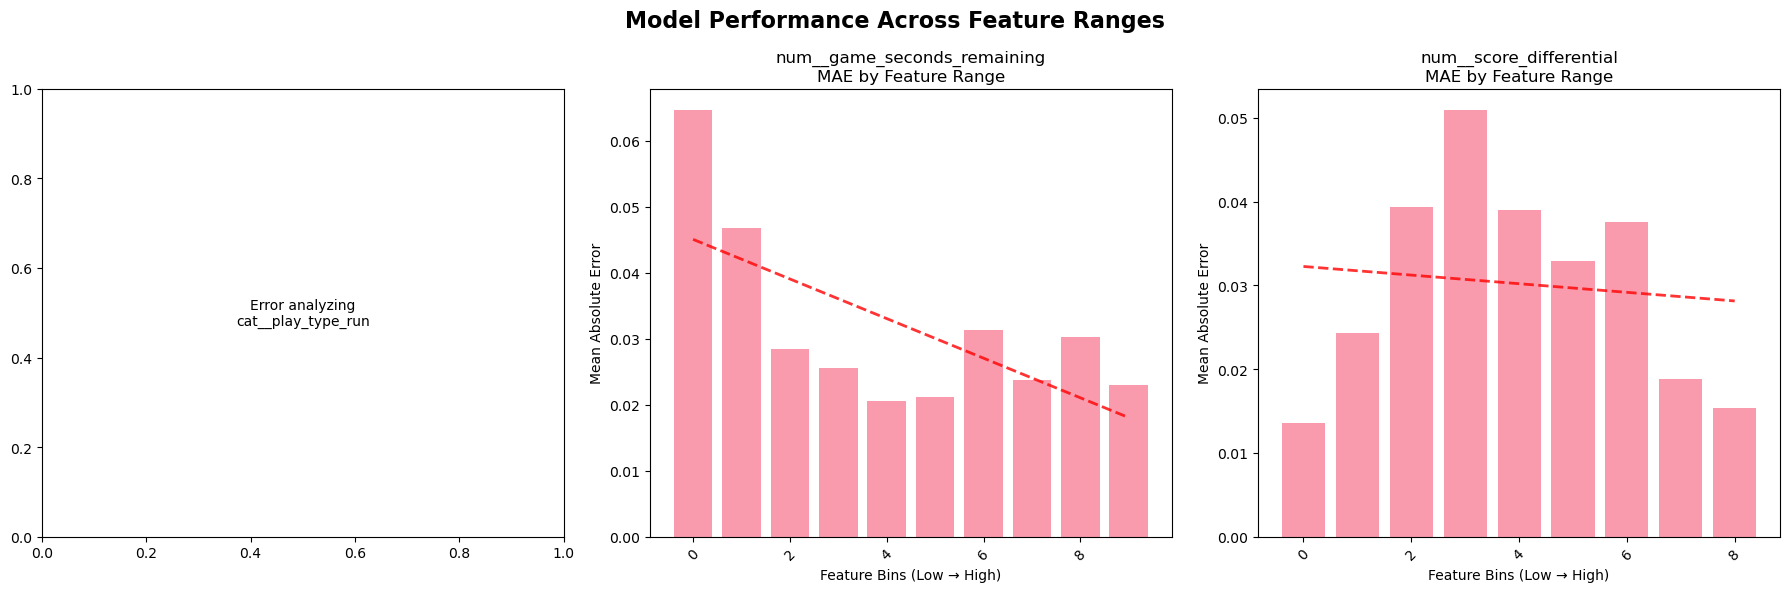


🎯 OVERALL MODEL PERFORMANCE:
   Mean Absolute Error (MAE): 0.0316
   Root Mean Square Error (RMSE): 0.0579
   R² Score: -0.0697

💡 PERFORMANCE INSIGHTS:
   • Look for features where error increases at extremes
   • Consider non-linear transformations for features with trends
   • High error ranges might need more training data


In [23]:
# Model Performance by Feature Ranges
print("📊 MODEL PERFORMANCE BY FEATURE RANGES")
print("=" * 50)
print("Understanding how model performs across different feature value ranges")

try:
    # Get predictions for test set
    y_pred = model.predict(X_test)
    
    # Calculate residuals
    residuals = y_test - y_pred
    
    # Analyze performance across ranges of top features
    top_3_features = importance_df.head(3)['feature'].tolist()
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Model Performance Across Feature Ranges', fontsize=16, fontweight='bold')
    
    for i, feature_name in enumerate(top_3_features):
        try:
            # Find the feature index in the processed data
            if feature_name in feature_names:
                feature_idx = list(feature_names).index(feature_name)
                feature_values = X_test.iloc[:, feature_idx]
                
                # Create bins for the feature
                n_bins = 10
                feature_bins = pd.qcut(feature_values, q=n_bins, duplicates='drop')
                
                # Calculate mean absolute error by bin
                performance_by_bin = pd.DataFrame({
                    'feature_bin': feature_bins,
                    'residuals': residuals,
                    'abs_residuals': np.abs(residuals),
                    'predictions': y_pred,
                    'actuals': y_test
                })
                
                bin_stats = performance_by_bin.groupby('feature_bin').agg({
                    'abs_residuals': ['mean', 'std', 'count'],
                    'residuals': 'mean'
                }).round(4)
                
                # Plot
                bin_centers = [interval.mid for interval in bin_stats.index]
                mean_errors = bin_stats[('abs_residuals', 'mean')].values
                
                axes[i].bar(range(len(bin_centers)), mean_errors, alpha=0.7)
                axes[i].set_title(f'{feature_name}\nMAE by Feature Range')
                axes[i].set_xlabel('Feature Bins (Low → High)')
                axes[i].set_ylabel('Mean Absolute Error')
                axes[i].tick_params(axis='x', rotation=45)
                
                # Add trend line
                z = np.polyfit(range(len(mean_errors)), mean_errors, 1)
                p = np.poly1d(z)
                axes[i].plot(range(len(mean_errors)), p(range(len(mean_errors))), 
                           "r--", alpha=0.8, linewidth=2)
                
                print(f"\n📈 {feature_name} Performance Analysis:")
                print(f"   Best performing range: Bin {np.argmin(mean_errors) + 1} (MAE: {min(mean_errors):.4f})")
                print(f"   Worst performing range: Bin {np.argmax(mean_errors) + 1} (MAE: {max(mean_errors):.4f})")
                
                # Check for trend
                slope = z[0]
                if abs(slope) > 0.01:
                    trend = "increasing" if slope > 0 else "decreasing"
                    print(f"   Trend: Error {trend} with feature value (slope: {slope:.4f})")
                else:
                    print(f"   Trend: Relatively stable across feature range")
                    
        except Exception as e:
            axes[i].text(0.5, 0.5, f'Error analyzing\n{feature_name}', 
                        ha='center', va='center', transform=axes[i].transAxes)
            print(f"   ⚠️  Could not analyze {feature_name}: {e}")
    
    plt.tight_layout()
    plt.show()
    
    # Overall model performance summary
    mae = np.mean(np.abs(residuals))
    rmse = np.sqrt(np.mean(residuals**2))
    r2 = 1 - (np.sum(residuals**2) / np.sum((y_test - np.mean(y_test))**2))
    
    print(f"\n🎯 OVERALL MODEL PERFORMANCE:")
    print(f"   Mean Absolute Error (MAE): {mae:.4f}")
    print(f"   Root Mean Square Error (RMSE): {rmse:.4f}")
    print(f"   R² Score: {r2:.4f}")
    
    print(f"\n💡 PERFORMANCE INSIGHTS:")
    print(f"   • Look for features where error increases at extremes")
    print(f"   • Consider non-linear transformations for features with trends")
    print(f"   • High error ranges might need more training data")
    
except Exception as e:
    print(f"❌ Error in performance analysis: {e}")
    print("   Make sure y_test and predictions are available")

## Summary & Actionable Insights

Based on the feature analysis above, here are key insights for improving your model and understanding the data.

In [24]:
# Generate Actionable Insights Report
print("🎯 ACTIONABLE INSIGHTS & RECOMMENDATIONS")
print("=" * 60)

try:
    # Summarize key findings
    top_5_features = importance_df.head(5)
    
    print("📊 KEY FINDINGS:")
    print(f"\n1. 🏆 MOST IMPORTANT FACTORS:")
    for i, (_, row) in enumerate(top_5_features.iterrows(), 1):
        impact_level = "High" if row['importance'] > 0.1 else "Medium" if row['importance'] > 0.05 else "Low"
        print(f"   {i}. {row['feature']} (Impact: {impact_level}, Score: {row['importance']:.4f})")
    
    print(f"\n2. 📈 MODEL INSIGHTS:")
    if 'r2' in locals():
        model_quality = "Excellent" if r2 > 0.8 else "Good" if r2 > 0.6 else "Fair" if r2 > 0.4 else "Needs Improvement"
        print(f"   • Model Quality: {model_quality} (R² = {r2:.3f})")
        print(f"   • Average Prediction Error: {mae:.4f}")
    
    # Count feature importance distribution
    high_impact = len(importance_df[importance_df['importance'] > 0.1])
    medium_impact = len(importance_df[importance_df['importance'].between(0.05, 0.1)])
    low_impact = len(importance_df[importance_df['importance'] < 0.05])
    
    print(f"   • High impact features: {high_impact}")
    print(f"   • Medium impact features: {medium_impact}")  
    print(f"   • Low impact features: {low_impact}")
    
    print(f"\n3. 🔧 RECOMMENDATIONS FOR MODEL IMPROVEMENT:")
    
    # Feature selection recommendations
    features_80_pct = threshold_80[0] + 1 if len(threshold_80) > 0 else len(feature_names)
    if features_80_pct < len(feature_names) * 0.8:
        print(f"   • Consider feature selection: {features_80_pct} features explain 80% of importance")
        print(f"     → Remove {len(feature_names) - features_80_pct} least important features")
    
    # High correlation recommendations
    if 'high_corr_pairs' in locals() and high_corr_pairs:
        print(f"   • Address multicollinearity: {len(high_corr_pairs)} highly correlated feature pairs found")
        print(f"     → Consider removing redundant features or using PCA")
    
    # Performance stability recommendations
    print(f"   • Monitor model performance across feature ranges")
    print(f"     → Collect more data for ranges with high prediction errors")
    
    print(f"\n4. 🎯 BUSINESS/FOOTBALL INSIGHTS:")
    
    # Interpret top features for football context
    football_insights = {
        'field_position': "Field position is crucial - closer to goal = higher win probability",
        'score_differential': "Score difference drives decision-making and outcomes",
        'game_seconds_remaining': "Time pressure significantly affects game dynamics",
        'down': "Down and distance create different strategic situations",
        'ydstogo': "Yards to go for first down influences play selection",
        'wp': "Win probability captures game momentum and situation",
        'ep': "Expected points reflect field position value",
        'qtr': "Quarter affects time management and strategy"
    }
    
    for feature_name in top_5_features['feature']:
        for key, insight in football_insights.items():
            if key.lower() in feature_name.lower():
                print(f"   • {insight}")
                break
    
    print(f"\n5. 💡 NEXT STEPS FOR ANALYSIS:")
    print(f"   • Run SHAP analysis for individual prediction explanations")
    print(f"   • Create partial dependence plots for non-linear relationships")
    print(f"   • Analyze feature interactions for combination effects")
    print(f"   • Test different XGBoost hyperparameters based on feature insights")
    print(f"   • Consider feature engineering based on domain knowledge")
    
    # Export feature importance for further use
    try:
        importance_df.to_csv('/tmp/feature_importance.csv', index=False)
        print(f"\n💾 Feature importance saved to: /tmp/feature_importance.csv")
    except:
        pass
    
    print(f"\n🏈 FOOTBALL-SPECIFIC RECOMMENDATIONS:")
    print(f"   • Focus on situational features (field position, time, score)")
    print(f"   • Consider adding interaction terms (e.g., down × ydstogo)")
    print(f"   • Include team-specific features for better predictions")
    print(f"   • Add weather/environmental factors if available")
    
except Exception as e:
    print(f"❌ Error generating insights: {e}")

print(f"\n" + "="*60)
print(f"🎉 FEATURE ANALYSIS COMPLETE!")
print(f"Use these insights to improve your model and understanding of NFL data.")
print(f"="*60)

🎯 ACTIONABLE INSIGHTS & RECOMMENDATIONS
📊 KEY FINDINGS:

1. 🏆 MOST IMPORTANT FACTORS:
   1. cat__play_type_run (Impact: High, Score: 0.1379)
   2. num__game_seconds_remaining (Impact: High, Score: 0.1284)
   3. num__score_differential (Impact: High, Score: 0.1278)
   4. cat__play_type_field_goal (Impact: High, Score: 0.1186)
   5. cat__play_type_pass (Impact: High, Score: 0.1165)

2. 📈 MODEL INSIGHTS:
   • Model Quality: Needs Improvement (R² = -0.070)
   • Average Prediction Error: 0.0316
   • High impact features: 7
   • Medium impact features: 2
   • Low impact features: 1

3. 🔧 RECOMMENDATIONS FOR MODEL IMPROVEMENT:
   • Consider feature selection: 7 features explain 80% of importance
     → Remove 3 least important features
   • Monitor model performance across feature ranges
     → Collect more data for ranges with high prediction errors

4. 🎯 BUSINESS/FOOTBALL INSIGHTS:
   • Time pressure significantly affects game dynamics
   • Score difference drives decision-making and outcom